# Twilight Forecast History

**Authors:** Brian Brondel, B. Stalder

Queries the Rubin Observatory EFD for historical `WeatherForecast.hourlyTrend` temperature predictions and shows how successive forecasts estimated the temperature at the end of evening nautical twilight.

## Imports & Constants

Standard scientific Python stack plus Astropy for solar-position calculations, SciPy's Brent root-finder for precise twilight crossing times, and the LSST EFD client for telemetry queries.

Key constants:
- `DELTA_TIME` – 5-minute cadence of the `hourlyTrend` temperature grid.
- `NAUTICAL_TWILIGHT_DEG` / `ASTRONOMICAL_TWILIGHT_DEG` – sun-altitude thresholds (−12° and −18°) used as the forecast target time.
- `RUBIN` – ITRS location of the Vera C. Rubin Observatory on Cerro Pachón.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import AltAz, EarthLocation, get_sun
from astropy.time import Time, TimeDelta
from scipy.optimize import brentq

from lsst_efd_client import EfdClient

DELTA_TIME = 5 * 60  # seconds between hourlyTrend.temperature samples
ASTRONOMICAL_TWILIGHT_DEG = -18.0
NAUTICAL_TWILIGHT_DEG = -12.0
RUBIN = EarthLocation.of_site("Rubin")

## Configuration

Set the EFD instance and the query time window. `START`/`END` default to the past 8 hours relative to now; adjust them to inspect a specific night. Change `EFD_NAME` to `"summit_efd"` when running at the summit.

In [2]:
# Query window (UTC). Adjust as needed.
END = Time.now()
START = END - TimeDelta(8 * 3600, format="sec")

# EFD instance: "summit_efd", "usdf_efd", "tucson_teststand_efd", etc.
EFD_NAME = "usdf_efd"
TOPIC = "lsst.sal.WeatherForecast.hourlyTrend"

## Connect to EFD & Discover Fields

Open a connection to the chosen EFD instance and enumerate all `temperature*` fields published in `hourlyTrend`. The fields are sorted by their integer suffix so they correspond to consecutive 5-minute forecast steps ahead of the publication timestamp.

In [3]:
client = EfdClient(EFD_NAME)
fields = await client.get_fields(TOPIC)
temperature_fields = sorted(
    [f for f in fields if f.startswith("temperature") and f[len("temperature"):].isdigit()],
    key=lambda f: int(f[len("temperature"):]),
)
print(f"Found {len(temperature_fields)} temperature grid points per sample.")

Found 1008 temperature grid points per sample.


## Fetch Forecast Data

Query the EFD for all `hourlyTrend` messages published in the configured time window. Each row is one forecast issuance: `private_sndStamp` is the UTC Unix timestamp when the SAL publisher sent the message, and the `temperature0…temperatureN` columns contain the predicted temperatures at successive 5-minute steps ahead.

In [4]:
df = await client.select_time_series(
    TOPIC,
    ["private_sndStamp"] + temperature_fields,
    START,
    END,
)
print(f"Fetched {len(df)} hourlyTrend samples.")
df.head()

Fetched 27 hourlyTrend samples.


,private_sndStamp,temperature0,temperature1,temperature2,temperature3,temperature4,temperature5,temperature6,temperature7,temperature8,...,temperature998,temperature999,temperature1000,temperature1001,temperature1002,temperature1003,temperature1004,temperature1005,temperature1006,temperature1007
2026-05-26 09:26:49.624638+00:00,1.779788e+09,12.328497,12.324671,12.321229,12.318328,12.316127,12.314791,12.314486,12.315375,12.317628,...,None,None,None,None,None,None,None,None,None,None
2026-05-26 09:44:18.426417+00:00,1.779789e+09,12.463575,12.465217,12.467757,12.471359,12.476187,12.482404,12.490170,12.499646,12.510985,...,None,None,None,None,None,None,None,None,None,None
2026-05-26 10:02:14.021318+00:00,1.779790e+09,12.533527,12.539756,12.547379,12.556553,12.567434,12.580174,12.594919,12.611806,12.630966,...,None,None,None,None,None,None,None,None,None,None
2026-05-26 10:20:11.721549+00:00,1.779791e+09,12.651047,12.664319,12.679435,12.696532,12.715746,12.737201,12.761013,12.787291,12.816129,...,None,None,None,None,None,None,None,None,None,None
2026-05-26 10:37:41.326239+00:00,1.779792e+09,12.724415,12.744596,12.766990,12.791705,12.818840,12.848483,12.880711,12.915586,12.953162,...,None,None,None,None,None,None,None,None,None,None


## Helper Functions

Three utilities used in the computation step:

- **`sun_altitude_deg(t)`** – returns the sun's altitude above the horizon (degrees) at time `t` from Rubin's location, using pressure = 0 to skip atmospheric refraction.
- **`next_end_of_evening_twilight(after, target_alt)`** – scans forward hour-by-hour from `after` to bracket the next descending solar crossing of `target_alt`, then pinpoints it to sub-second precision with Brent's method.
- **`interp_at(temperatures, sndstamp_unix, target_unix)`** – linearly interpolates the temperature array at the fractional grid index corresponding to `target_unix`, exactly replicating the `WeatherForecastModel.predict_temperature_at_time` method.

In [5]:
def sun_altitude_deg(t: Time) -> float:
    sun = get_sun(t)
    return sun.transform_to(AltAz(obstime=t, location=RUBIN, pressure=0)).alt.deg


def next_end_of_evening_twilight(after: Time, target_alt: float = NAUTICAL_TWILIGHT_DEG) -> Time:
    """Next time the sun crosses `target_alt` while descending, after `after`."""
    t0 = after + 1 * u.s
    alt_before = sun_altitude_deg(t0)
    for i in range(1, 26):
        t1 = t0 + i * u.hour
        alt_after = sun_altitude_deg(t1)
        if alt_before > target_alt and alt_after < target_alt:
            break
        alt_before = alt_after
    else:
        raise RuntimeError("No descending crossing found in next 25 hours.")

    def f(t_sec: float) -> float:
        return sun_altitude_deg(Time(t_sec, format="unix")) - target_alt

    return Time(brentq(f, (t1 - 1 * u.hour).unix, t1.unix), format="unix")


def interp_at(temperatures: np.ndarray, sndstamp_unix: float, target_unix: float):
    """Linear interpolation matching WeatherForecastModel.predict_temperature_at_time."""
    index_float = (target_unix - sndstamp_unix) / DELTA_TIME - 1
    if index_float < 0 or index_float > len(temperatures) - 1:
        return np.nan
    return float(np.interp(index_float, np.arange(len(temperatures)), temperatures))

## Compute Predicted Twilight Temperatures

For every forecast issuance in the dataset:
1. Compute the next end-of-evening nautical twilight after the message's send timestamp.
2. Interpolate the forecast's temperature grid at that twilight moment.

Results are assembled into a tidy DataFrame with columns for publication time, the predicted twilight time, and the predicted temperature.

In [6]:
snd = df["private_sndStamp"].to_numpy(dtype=float)
temps = df[temperature_fields].to_numpy(dtype=float)

predictions = np.empty(len(df))
twilights = np.empty(len(df))
for i in range(len(df)):
    twilights[i] = next_end_of_evening_twilight(Time(float(snd[i]), format="unix")).tai.unix
    predictions[i] = interp_at(temps[i], float(snd[i]), twilights[i])

result = pd.DataFrame(
    {
        "publication_time": pd.to_datetime(snd, unit="s", utc=True),
        "twilight_time": pd.to_datetime(twilights, unit="s", utc=True),
        "predicted_twilight_temperature": predictions,
    }
).sort_values("publication_time")
result.head()

,publication_time,twilight_time,predicted_twilight_temperature
0,2026-05-26 09:27:26.624638081+00:00,2026-05-26 22:47:17.490734100+00:00,13.190609
1,2026-05-26 09:44:55.426416636+00:00,2026-05-26 22:47:17.490734100+00:00,13.561901
2,2026-05-26 10:02:51.021317720+00:00,2026-05-26 22:47:17.490734339+00:00,13.477278
3,2026-05-26 10:20:48.721549273+00:00,2026-05-26 22:47:17.490734100+00:00,13.578182
4,2026-05-26 10:38:18.326239347+00:00,2026-05-26 22:47:17.490733862+00:00,13.304175


## Visualisation

Plot the predicted twilight temperature as a function of forecast publication time. Each point represents one `hourlyTrend` issuance; the trend shows how the model's estimate of tonight's opening temperature evolved as successive forecasts were published throughout the day.

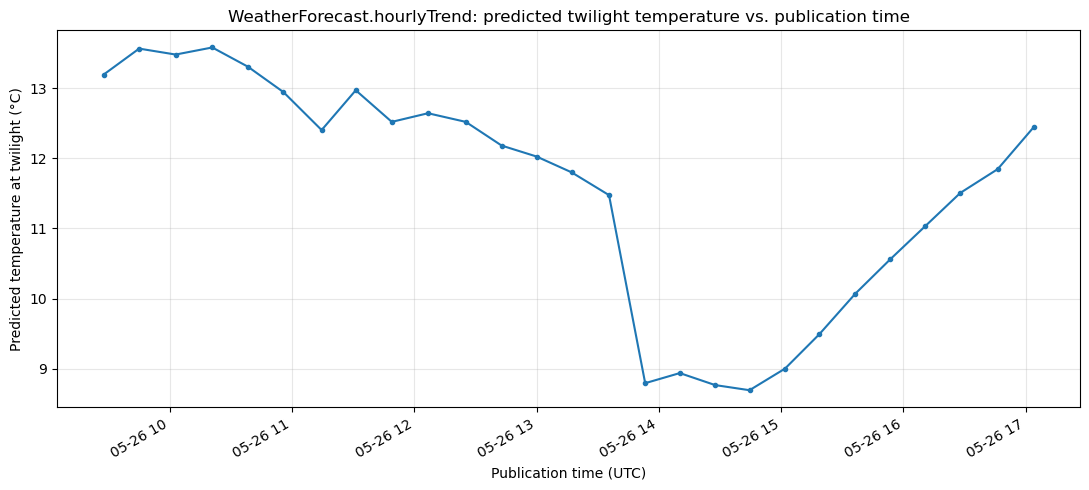

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
valid = result.dropna(subset=["predicted_twilight_temperature"])

ax.plot(
    valid["publication_time"],
    valid["predicted_twilight_temperature"],
    marker=".",
    linestyle="-",
)

ax.set_xlabel("Publication time (UTC)")
ax.set_ylabel("Predicted temperature at twilight (°C)")
ax.set_title("WeatherForecast.hourlyTrend: predicted twilight temperature vs. publication time")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()